## Lecture 8

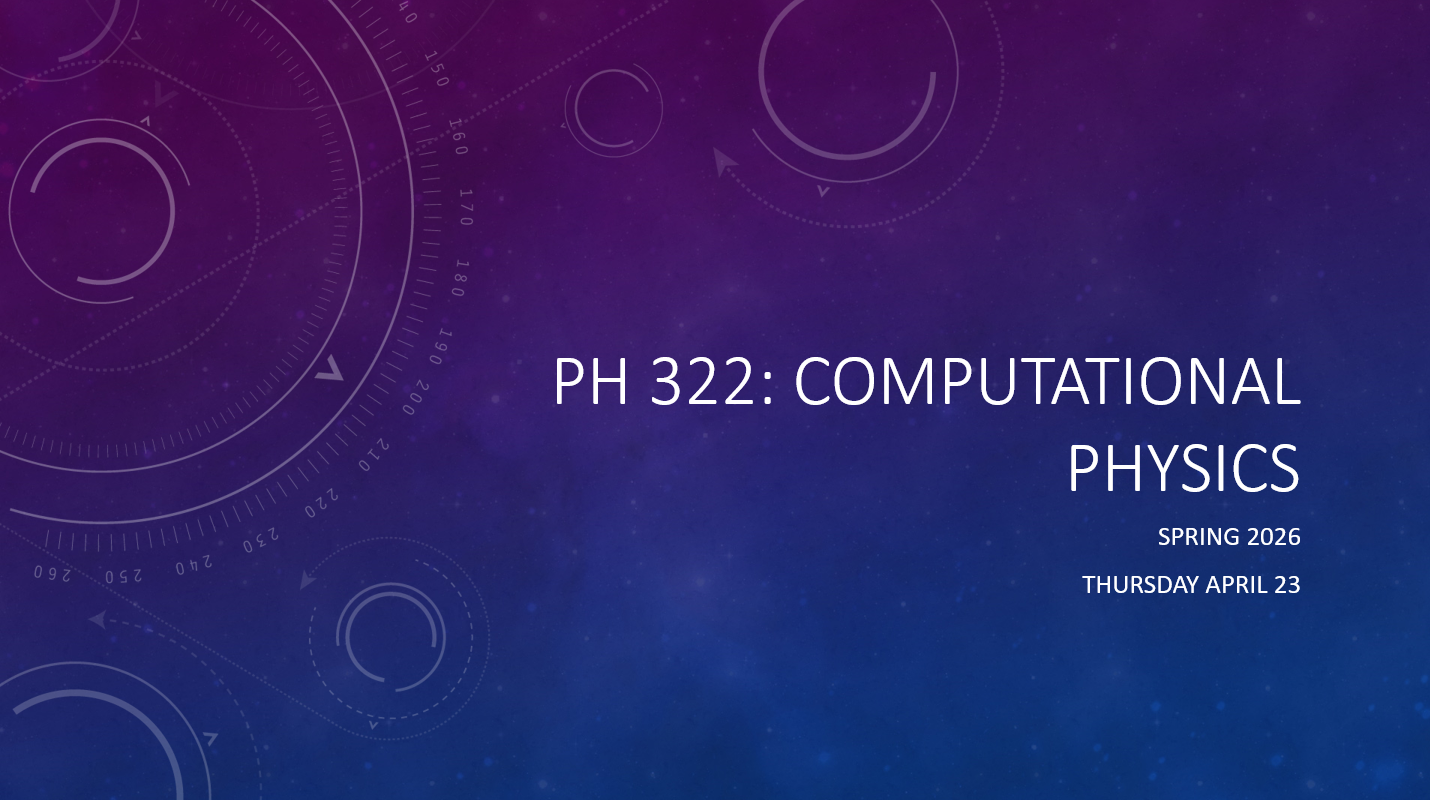

In [1]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Lectures\\Figures\\header_lecture8.png"))

HW4 available - Due Tuesday, Apr 28

**Last class**
* Taylor series.
* Approximation errors.
* Euler-McClaurin method.
* Doubling method.



**Today**
* Gaussian quadrature.
* Computing integrals over infinite ranges.
* Computing double integrals.



## Gaussian quadrature 

Let's review.

The trapezoidal rule is a first-order integration method. We derived it by fitting the integrand with a straight line over each integration slice.

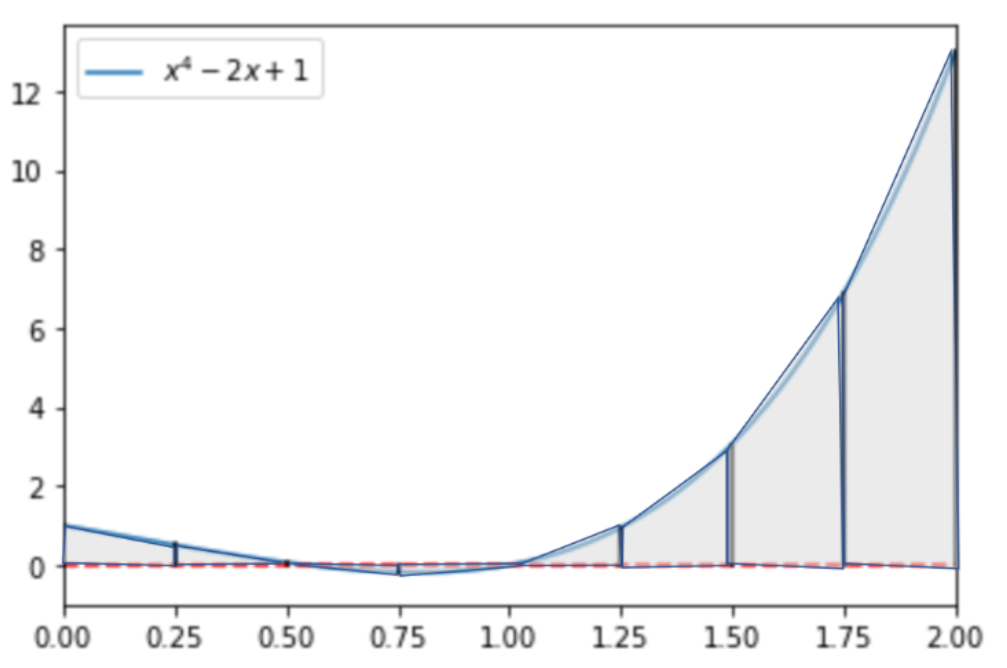


Simpson's rule is a third-order integration rule. We derived it by fitting the integrand wtih a quadratic, which is a second-order polynomial over each integration slice. 


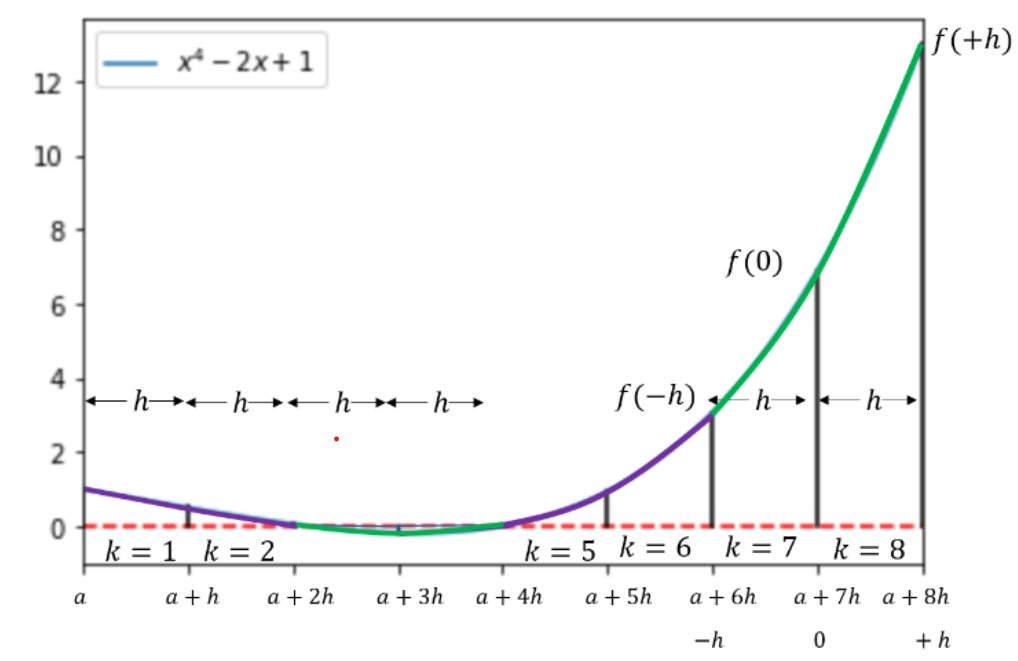


Let's compare the two

**Trapezoidal Rule** 

$$
I_{a,b} = h\left[\frac{1}{2}f(a)+\frac{1}{2}f(b)  +  \sum_{k=1}^{N-1} f(a+kh) \right]
$$ 

**Simpson's Rule**  
$$
I_{a,b} = \frac{1}{3}h\left[f(a) + f(b) + 2\sum_{k=2, \text{even k}}^{N-2} f(a+kh) + 4\sum_{k=1, \text{odd k}}^{N-1} f(a+kh)\right]
$$


Notice that every term in both rules is the integrand $f(x)$ evaluated at a sample point, multiplied by some pre-factor. For example the first term of the trapezoidal rule is the integrand evaluated at sample point $a$ multiplied by $\frac{h}{2}$, while the pre-factor is just h for every term in the sum.

Likewise the pre-factor on the first term in Simpson's Rule is $\frac{h}{3}$, while the pre-factors on the odd and even slices are $\frac{2h}{3}$ and $\frac{4h}{3}$, respectively.

In general we can write both rules in this form:

$$
\int_a^b f(x) dx \approx \sum_{k=1}^{N} w_{k}f(x_k)
$$

where $x_k$ are the sample points, and $w_k$ is the pre-factor or the *weight* multiplying the $k$th term.

In general, **we approximate the integral by sampling the integrand at a number of sampling points, and multiply each sample by an appropriate weight.**

We can see how this weighting system works by plotting the weights, i.e. the coefficients, at the sample points, for each rule.

We'll start first with the trapezoidal rule:


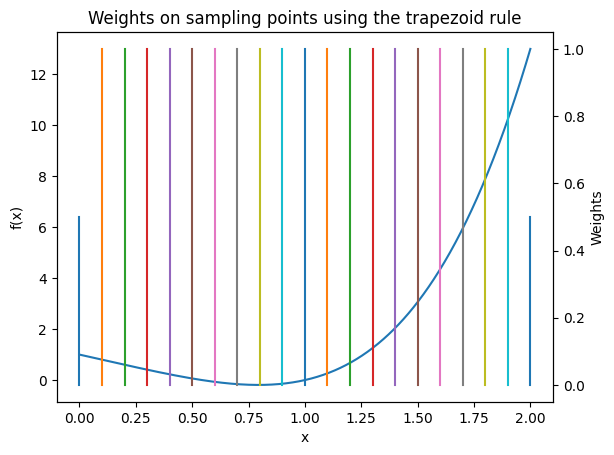

In [2]:
# Plot sampling points and weights of trapezoidal rule

import numpy as np
import matplotlib.pyplot as plt

# define the function in the integrand
def f(x):
    return x**4-2*x+1

# set the limits of integration
a=0
b=2
# set N
N=int(input("Number of slices: "))  

h = (b-a)/N

# populate arrays with x and y values of function
xvalues = np.linspace(a, b, 1000)
yvalues = f(xvalues)

# get the axes object so we can define a 2nd y-axis
ax1 = plt.gca()
ax1.plot (xvalues, yvalues)

# next define the sampling points and store in array
xp = np.arange(a,b+h,h)
# create an array of same size to hold the weights and initialize to 1
wp = np.full([len(xp)], 1.0)

# specify weights at endpoints
wp[0]=1/2
wp[N]=1/2
 
# create a second y-axis
ax2 = ax1.twinx()
#print ("sum of weights= ", sum(wp))

# Plot the weights on second y-axis
for i in range(0,len(xp)):
    ax2.plot ([xp[i],xp[i]], [0,wp[i]], '-')
    
ax1.set_xlabel("x")
ax1.set_ylabel("f(x)")
ax2.set_ylabel("Weights")
plt.title("Weights on sampling points using the trapezoid rule")
plt.show()

Notice that all the weights are equal to 1 except at end points.  Also, all sampling points are equally spaced.

Let's repeat but now for Simpson's Rule:

Number of slices:  20


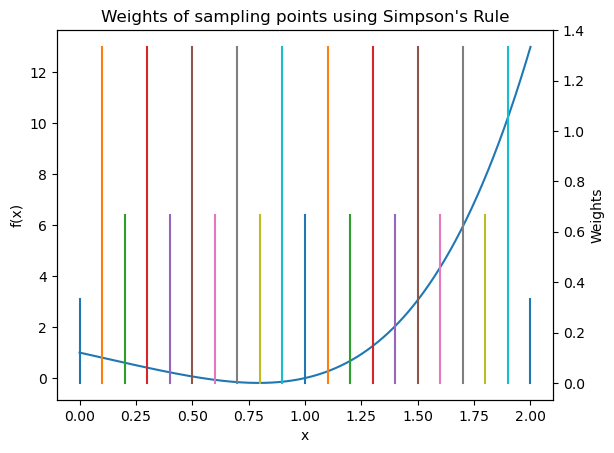

In [7]:
# Plot sampling points and weights of Simpson's rule

import numpy as np
import matplotlib.pyplot as plt

# define the function in the integrand
def f(x):
    return x**4-2*x+1

# set the limits of integration
a=0
b=2
# set N
N=int(input("Number of slices: ")) 

h = (b-a)/N

# populate arrays with x and y values of function
xvalues = np.linspace(a, b, 1000)
yvalues = f(xvalues)

# get the axes object so we can define a 2nd y-axix
ax1 = plt.gca()
ax1.plot (xvalues, yvalues)

# define sampling points
xp = np.arange(a,b+h,h)
# create array of equal size to store weights and initialize to 1/3
wp = np.full([len(xp)], 1/3)

# change weights of even and odd terms
for k in range(1,N):
    if k%2 == 0:
        wp[k]=2/3
    if k%2 == 1:
        wp[k]=4/3
        
# create a second y-axis
ax2 = ax1.twinx()
#print ("sum of weights= ", sum(wp))

# Plot the weights on second y-axis
for i in range(0,len(xp)):
    ax2.plot ([xp[i],xp[i]], [0,wp[i]], '-')
    
ax1.set_xlabel("x")
ax1.set_ylabel("f(x)")
ax2.set_ylabel("Weights")
plt.title("Weights of sampling points using Simpson's Rule")
plt.show()

Again, the weights are smallest at the endpoints, but here the weights alternate between even and odd values of $k$ for $x_k$.

We see that our integration rules are really just different sets of weights applied to the function where we evaluate it at  our sampling points.

Notice that if our integrand is a straight line, then the trapezoidal rule would provide an exact estimate of the integral.

sum of weights=  1.0


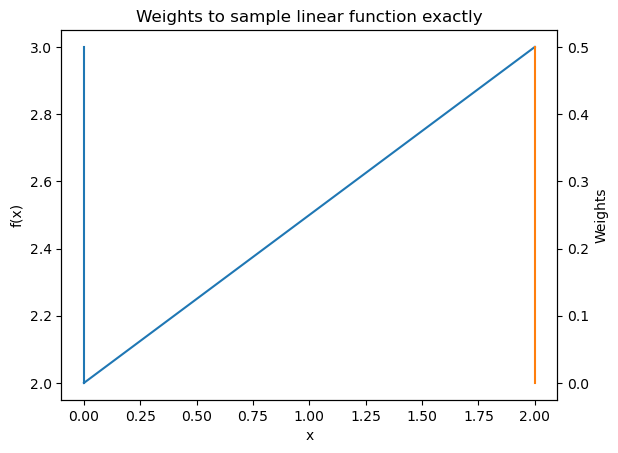

In [8]:
import numpy as np
import matplotlib.pyplot as plt
# a straight line
def f(x):
    m = 0.5
    c = 2
    return m*x + c


N = 1
a = 0
b = 2
h = (b-a)/N

# populate arrays with x and y values of function
xvalues = np.linspace(a, b, 100)
yvalues = f(xvalues)

# get the axes object so we can define a 2nd y-axix
ax1 = plt.gca()
ax1.plot (xvalues, yvalues)


# next calculate the sampling points and store in array
xp = np.arange(a,b+h,h)
wp = np.zeros([len(xp)], float)

# initially set all weights to 1
wp.fill(1)
# change weights at endpoints
wp[0]=1/2
wp[N]=1/2
 
# create a second y-axis
ax2 = ax1.twinx()
print ("sum of weights= ", sum(wp))

# Plot the weights on second y-axis
for i in range(0,len(xp)):
    ax2.plot ([xp[i],xp[i]], [0,wp[i]], '-')
    
ax1.set_xlabel("x")
ax1.set_ylabel("f(x)")
ax2.set_ylabel("Weights")
plt.title("Weights to sample linear function exactly")
plt.show()
#inc=4
#for x in np.arange(0, b+inc, inc): 
#    plt.plot([x,x], [0,f(x)], 'k')

Notice we would only need two sample points to fit this. 

And if the integrand was quadratic we only need three samples points.

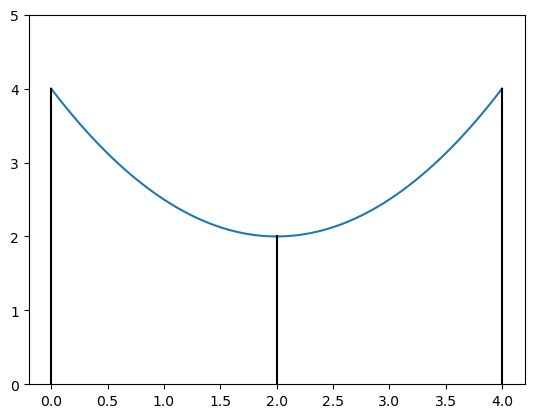

In [9]:
# a quadratic
def f(x):
    a = 0.5
    b = -2
    c = 4
    return a*x**2 + b*x +c

a=0
b=4
xvalues = np.linspace(0, b, 100)
yvalues = f(xvalues)

plt.plot (xvalues, yvalues)
plt.ylim(0,5)
inc=2
for x in np.arange(0, b+inc, inc): 
    plt.plot([x,x], [0,f(x)], 'k')

We would only need three sampling points to fit a quadratic.

In general we can fit a polynomial of order $N-1$  with $N$ sampling points. 

Until now we've assumed that our sampling points are evenly spaced. But what if we allow them to be spaced unevenly? 

For $N$ sampling points, we would have another $N$ degrees of freedom, for a total of 2N degrees of freedom. This may mean that we could fit polynomials up to power $2N-1$ with $N$ sampling points, not just polynomials of power $N-1$ that we can with evenly-spaced sampling points. If so, we can get a lot more "bang for our buck" with each sampling point, producing a faster more accurate method to estimate integrals.

This is the gist of the integration method called **Gaussian quadrature** (note "quadrature" refers to any numerical integration method). We not only choose how many sampling points to use, but *how* they are spaced. This produces one of the most accurate integration methods available.

The **magic** of Gaussian quadrature is we can find an integration rule that exactly calculates the integral of a polynomial of degree $2N-1$ (within rounding error) using only $N$ sampling points. If our function is not a polynomial, the rule still works, but there will be additional approximation error due to approximating the function with a polynomial.

Let's do a quick demonstration before we derive the method.

Let's go back to the integral:

$$
\int_a^b (x^4 -2^x+1)dx
$$

and estimate with the Gaussian quadrature method. 

**Note** to run this you need to download the ```gaussxw``` module. See directions below. 

Remember to ask about getting an exact approximation to a function degree 4 2n-1 stuff. 

In [12]:
# estimate integral using Gaussian quadrature

# Note: You need to download this module from Canvas
from gaussxw import gaussxw

#define our function
def f(x):
    return x**4 - 2*x + 1

exact = 4.4

# number of sampling points
N = int(input("How many sampling points do you wish to use?: ")) 

# integration interval
a = 0
b = 2

# Calculate the Gaussian quadrature sample points and weights, then map the points and weights
# to the required integration domain
x,w = gaussxw(N)
xp = 0.5*(b-a)*x + 0.5*(b+a)
wp = 0.5*(b-a)*w

# initialize the sum
s = 0.0

# Estimate integral using quadrature
for k in range(N):
    s += wp[k]*f(xp[k])

print(f"Using N = {N} the estimate of the integral is {s:0.3f}.")
print(f"The approximation error is {100*abs(exact-s)/exact:.2e}%.")


How many sampling points do you wish to use?:  3


Using N = 3 the estimate of the integral is 4.400.
The approximation error is 1.61e-13%.


A few things to note:

1. You see the integral is just the sum of the integrand evaluated at the sampling points multiplied by a set of weights. In other words, this has the same form as our trapezoidal rule, Simpson's rule, and higher order rules.
2. We only need 3 sampling points to estimate the integral down to rounding error. 
3. With only 3 sampling points, we would not be able to derive the equation for the polynomial, but we can calculate its integral. Seems like magic!


Just to remind you how poorly the trapezoid rule does using three sampling points (or 2 slices) let's rerun it:

In [13]:
# use trapezoidal rule to integrate

# define the function in the integrand
def f(x):
    return x**4-2*x+1

# set the limits of integration
a=0
b=2

# number of sampling points
N = int(input("How many slices do you wish to use?: ")) 

# calculate width of each slice
h = (b-a)/N

Isum=0
# perform the summation from k=1, N-1
for k in range(1, int(N)):
    Isum += f(a+k*h)

# Multiply through by h and add the end terms
I = h*(0.5*(f(a) + f(b)) +Isum)
print(f"Using the trapezoid rule and N={N}, the estimate of the integral is {I}")
print(f"The relative error is {abs(100*(4.4-I)/4.4):0.1f}%.") 

How many slices do you wish to use?:  3


Using the trapezoid rule and N=3, the estimate of the integral is 5.572016460905349
The relative error is 26.6%.


As expected the trapezoidal rule performs poorly producing an estimate with an error of nearly 60%.

So how is the GQ able to produce such accurate results with so few sampling points?

Let's take a look at the sampling points used in GQ. 

*xp* is the array that holds the sampling points in the program above. Let's plot these:

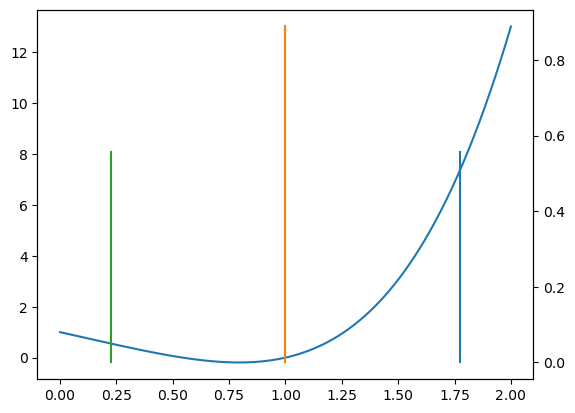

In [14]:
# Plot sampling points and weights used in Gaussian Quadrature

npoints = 1000
xpoints = np.linspace(a, b, npoints)
ypoints = f(xpoints)

# grab the current axes
ax1 = plt.gca()
# create a new axes that shares x=axis with ax1
ax2 = ax1.twinx()

# plot the function on ax1
ax1.plot (xpoints, ypoints)

# Draw a line at each sampling point, extending up to the weight of the sampling point
for i in range(len(xp)):
    ax2.plot ([xp[i],xp[i]], [0,wp[i]], '-')

The curved line is the function we're integrating from a=0 to b=2. The vertical lines are located at the sampling points $x_p$. 

Notice there are three lines corresponding to our three sampling points. 

Also note that the sampling points are not evenly spaced. The outer points are spaced about 0.25 away from the end points $a$ and $b$, while the middle point is spaced about 0.75 from these. 

It is the uneven spacing of the sampling points that makes all the difference. The spacing is optimized to produce the most accurate approximation. That's where the magic lies.  

The heights of the vertical lines are the weights $w_k$ that multiply the value of the integrand at each sampling point. We see the middle sampling point has a higher weight than the others. 

With $N$ sampling points the method can give exact answers up to polynomials of order $2N-1$, which for $N=3$ is a 5th-order polynomial. The function we integrated, $x^4-2x^2 + 1$ is only 4th-order, so we would expect it to produce a nearly exact solution, which it did.

Supposedly, using N=3 sampling points we can get an exact solution for a 5th-order polynomial. We will replace the integrand above with a 5th-order polynomial and retry.

In [16]:
# estimate integral using Gaussian quadrature
from gaussxw import gaussxw

#define our function
#def f(x):
#    return x**4 - 2*x + 1

#define a 5th-order function
def f(x):
    return x**5 + 1


# number of sampling points
N = 3

# integration interval
a = 0
b = 2

# true value of integral
true5 = 64/6 +2

# Calculate the sample points and weights, then map them
# to the required integration domain
x,w = gaussxw(N)

# remap the sampling points and weights to new integration interval
xp = 0.5*(b-a)*x + 0.5*(b+a)
wp = 0.5*(b-a)*w

# initialize the sum
s = 0.0

# Perform the Gaussian Quadrature
for k in range(N):
    s += wp[k]*f(xp[k])

print(f"The estimate of the integral is {s:0.2f} using N={N}.")
#print(f"The approximation error is {100*abs((4.4-s)/4.4):.2f}%.")
print(f"The approximation error is {100*abs((true5-s)/true5):.2e}%.")

The estimate of the integral is 12.67 using N=3.
The approximation error is 1.54e-13%.


Pretty good, the approximation error is near the rounding error.

Let's also see how the weights and the spacing of the sampling points change as we change the number of sampling points. 

In the program below we can experiment with the number of sampling points $N$, to see how the weights and locations of the sampling points change.

Play around and change the integration limits $a$ and $b$ as well.

How many sampling points?:  25


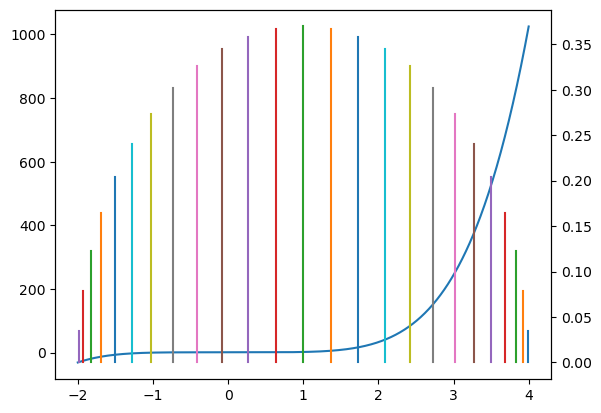

In [17]:
# Plot sampling points and weights

#def f(x):
#    return x**4 - 2*x + 1

#define a 5th-order function
def f(x):
    return x**5 + 1

    
# this first part plots the integrand
a = -2
b = 4

npoints = 1000
xpoints = np.linspace(a, b, npoints)
ypoints = f(xpoints)
ax1 = plt.gca()
ax2 = ax1.twinx()
ax1.plot (xpoints, ypoints)

N = int(input("How many sampling points?: "))

# Calculate the sample points and weights, then map them
# to the required integration domain
x,w = gaussxw(N)
xp = 0.5*(b-a)*x + 0.5*(b+a)
wp = 0.5*(b-a)*w


# Plot the weights on second y-axis
# Resize the weights for visualization
#wp *= max(ypoints)
for i in range(0,len(xp)):
    ax2.plot ([xp[i],xp[i]], [0,wp[i]], '-')

Notice that even as we increase the number of sampling points, the basic pattern of weights and spacing remains the same. The points are spaced closer together near the ends of the interval and farther apart in the middle. The weight is always largest in the middle of the interval and lowest at the ends.

The pattern stays the same even as we change the integration interval, it is only scaled so it spans the new interval.

If we were to change the integrand (i.e., the function we are integrating), we would also find the weights and spacings remain constant. This means that for a given $N$ sampling points, we only need to calculate the weights and sampling points once. We can then rescale them to a new integration interval if we need to. 

So let's go over the basic algorithm we use for Gaussian quadrature:
1. Choose the number of sampling points N.
2. Find the sampling points $x_k$, and the weights $w_k$ for a standard integration interval, $a=-1$, $b=1$.
3. Rescale the sampling points and weights to the correct integration interval.
4. Calculate the integral using:

$$
I\sim\sum_{k=1}^{N}w_kf(x_k)
$$

The most difficult step is step 2, calculating the location of the sampling points and the weights. These are difficult to calculate. However, since the sampling points and weights are independent of the specific integrand you're integrating, there are tables of these. For example here [Table of weights and sampling points](https://pomax.github.io/bezierinfo/legendre-gauss.html).

However the author of our textbook has also provided a Python function, ```gaussxw```,  we can use to calculate the locations and weights of the sampling points, which is the preferred option. It's found in the ```gaussxw``` module you can download from the author's website:

[gaussxw.py](http://www-personal.umich.edu/~mejn/cp/programs/gaussxw.py)

The file is also on our Canvas site. Put it in the same directory as your python script or notebook. 

The module contains two functions, ```gaussxw``` and ```gaussxwab```. They're both easy to use. The syntax of the first function is:

```python
gaussxw(N)
gaussxwab(N,a,b)
```

The only argument you have to pass to ```gaussxw``` is the number of sampling points $N$ you want. The function returns two 1D arrays each of size $N$, one holding the sampling point locations $x_k$, and the other the weights $w_k$.

You can use it like:

```python
xp, wp = gaussxw(N)
```

The function calculates $x$ and $w$ using a standard integration interval from a=-1 to b=1. 

I have already shown you code that uses Gaussian quadrature to estimate integrals. Let's take another look at that:

In [3]:
# quick demo of using function gaussxw to find the weights and locations
# of sampling points for Gaussian quadrature method

from gaussxw import gaussxw

# define the number of sampling points
N = 5

# call function gaussxw with N. gaussxw returns 2 1D arrays
# x_k will hold the locations of the sampling points
# w_k holds the weights
x_k, w_k = gaussxw(N)

print(f"Sampling points: {x_k}")
print(f"Weights: {w_k}")

Sampling points: [ 9.06179846e-01  5.38469310e-01 -8.97547387e-17 -5.38469310e-01
 -9.06179846e-01]
Weights: [0.23692689 0.47862867 0.56888889 0.47862867 0.23692689]


Unless (-1,1) is your integration interval, you will need to map both the $x_k$ and $w_k$ to your correct interval (a,b). 

The mapping rules are:

$
x'_k = \frac{1}{2}(b-a)x_k + \frac{1}{2}(b+a)
$

$
w'_k =\frac{1}{2}(b-a)w_k
$

where the unprimed $x_k$ and $w_k$ are the values calculated over the standard interval (-1,1) and the primed values are those mapped to the specified integration interval (a,b)

In [15]:
# quick demo of using function gaussxw to find the weights and locations
# of sampling points for Gaussian quadrature method

from gaussxw import gaussxw

# define the number of sampling points
N = 5

# call function gaussxw with N. gaussxw returns 2 1D arrays
# x_k will hold the locations of the sampling points
# w_k holds the weights
x_k, w_k = gaussxw(N)

# map sampling locations and weights to correct integration interval
a = -2
b = 5

x_kp  = 0.5*(b-a)*x_k + 0.5*(b+a)
w_kp = 0.5*(b-a)*w_k

print(f"Original sampling points: {x_k}")
print(f"Scaled sampling points: {x_kp}")
print(f"Original weights: {w_k}")
print(f"Scaled weights: {w_kp}")

Original sampling points: [ 9.06179846e-01  5.38469310e-01 -8.97547387e-17 -5.38469310e-01
 -9.06179846e-01]
Scaled sampling points: [ 4.67162946  3.38464259  1.5        -0.38464259 -1.67162946]
Original weights: [0.23692689 0.47862867 0.56888889 0.47862867 0.23692689]
Scaled weights: [0.8292441  1.67520035 1.99111111 1.67520035 0.8292441 ]


In fact, this mapping is done for you if you use the second function ```gaussxwab(N,a,b)```. In addition to passing the number of sampling points $N$, you also pass your integration interval (a,b). The function returns the mapped values $x_k'$ and $w_k'$. 


In [4]:
# quick demo of using function gaussxw to find the weights and locations
# of sampling points for Gaussian quadrature method

from gaussxw import gaussxwab

# define the number of sampling points
N = 5

# define the integration interval
a = -2
b = 5
# call function gaussxwab with N,a,b. 
# Now the correct sampling locations and weights are returned.
# No need to map them into the correct interval.
x_k, w_k = gaussxwab(N,a,b)

print(f"Sampling points: {x_k}")
print(f"Weights: {w_k}")

Sampling points: [ 4.67162946  3.38464259  1.5        -0.38464259 -1.67162946]
Weights: [0.8292441  1.67520035 1.99111111 1.67520035 0.8292441 ]


### Overview of the Gaussian quadrature derivation 

The full details of how the Gaussian quadrature is derived are in the textbook. Here I provide a general schematic.

1. We want to generate an integration rule of the type above for a non-uniform set of $N$ sampling points $x_k$.

$$
\int_a^b f(x)dx \sim \sum_{k=1}^{N}w_kf(x_k)
$$

2. We sample the function $f(x)$ at the sampling points $x_k$. So we get a set of  $N$ points $f(x_k$).

3. We can fit $N$ points exactly with an $N-1$ polynomial, so that's what we do. Note this will be an exact fit to the $N$ points, but not necessarily an exact fit to the function $f(x)$. This is done using *interpolating polynomials*, $\phi_k(x)$, such that the fit is:

$$
\Phi(x) = \sum_{k=1}^{N}f(x_k)\phi_k(x)
$$


4. We then integrate this polynomial over our integration interval (a,b). This gives us an approximation to the true integral. The result of this step is:

$$
\int_a^b f(x)dx \sim \sum_{k=1}^{N}f(x_k)\underbrace{\int_a^b\phi_k(x)dx}_{w_k}
$$


Comparing this to the equation above, we see the weights $w_k$ in the integration rule above are given by:

$$
w_k = \int_a^b \phi_k(x) dx
$$

5. So given a set of sampling points $x_k$, this tells us how to calculate the weights. But where to place the sampling points? Suppose we approximate our integrand with a polynomial $f(x)$ of degree $2N-1$. Using polynomial dvision we can write $f(x)$ as:

$$
f(x) = q(x)P_N(x) + r(x)
$$

where $P_N(x)$ is a Legendre polynomial of degree $N$, and $q(x)$ and $r(x)$ are polynomials of degree $N-1$ or less. Legendre polynomials have the property:

$$
\int^1_{-1}x^kP_N(x)dx=0, \text{for all integers k in the range } 0 \le k \lt N.
$$


The polynomial $q(x)$ can be written:

$$
q(x) = \sum^{N=1}_{k=0} c_k x^k.
$$

Therefore when integrate $f(x)$:

$$
\int^1_{-1} f(x)dx = \int^1_{-1}q(x)P_N(x)dx + \int^1_{-1}r(x)dx
$$

$$
 =  \sum^{N=1}_{k=0} c_k \int^1_{-1} x^kP_N(x)dx + \int^1_{-1}r(x)dx
$$

The first term goes to zero due to the property of the Legendre polymial above. So the integration of the $2N-1$ polynomial reduces down to the integration of a $N-1$ polynomial, which we can calculate using the quadrature rule:

$$
\int^1_{-1} r(x)dx = \sum^N_{k=1} w_k r(x_k).
$$

We could stop there but $r(x_k)$ requires a polynomial division which is complicated. To simplify the problem further, we go back to our original integration rule:

$$
\int^1_{-1} f(x)dx = \sum^N_{k=1} w_k f(x_k) = \sum^N_{k=1}w_kq(x)P_N(x) + \sum^N_{k=1}w_k r(x)
$$
  
  
Legendre polynomial $P_N(x)$ has $N$ roots. If we choose our $N$ sampling points to be these roots, the first term on the RHS goes to zero, leaving:

$$
\sum^N_{k=1} w_k f(x_k) =  \sum^N_{k=1}w_k r(x)
$$  

But above, we saw that $\sum^N_{k=1}w_k r(x)$ is equivalent to the integral of the $2N-1$ polynomial $f(x)$, so:

$$ 
\boxed{ \int^1_{-1} f(x)dx = \sum^N_{k=1} w_k f(x_k) }
$$
   
This says that we can calculate the integral of a $2N-1$ degree polynomial using only $N$ sampling points if we chosoe the sampling points to coincide with the roots of $P_N(x)$. 

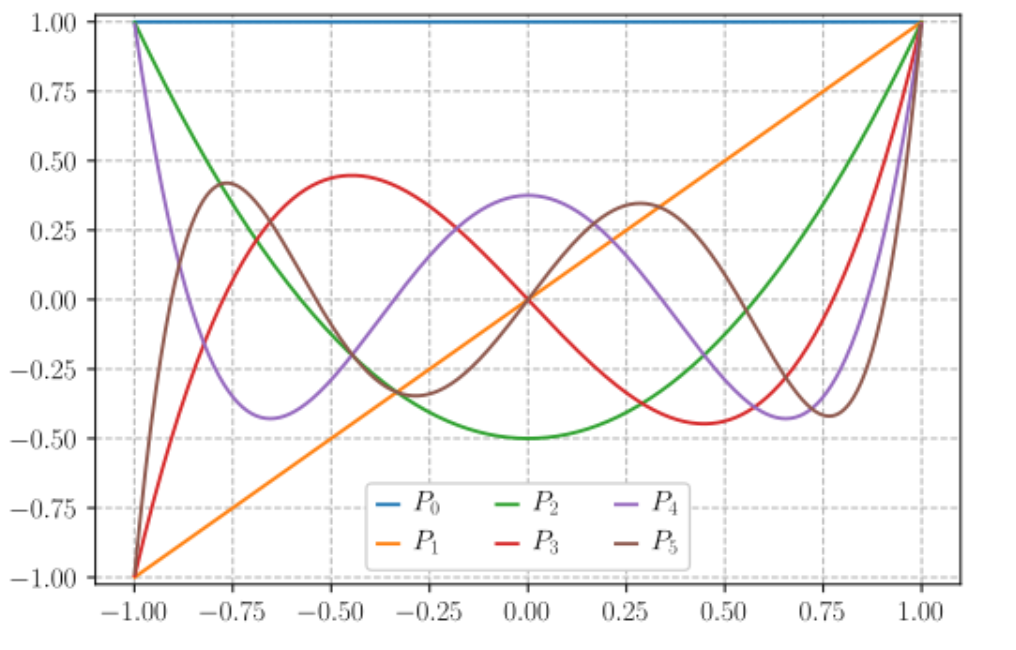

Image source: Wikipedia.


We can compare the locations of the roots with the locations of the sampling points in Gaussian quadrature using the ```gaussxw``` function which returns the N weights and sampling locations. Feel free to explore by changing N in the script. 



 Legrendre roots   Sampling points using gaussxw 
     -0.906                   -0.906             
     -0.538                   -0.538             
      0.000                   -0.000             
      0.538                    0.538             
      0.906                    0.906             


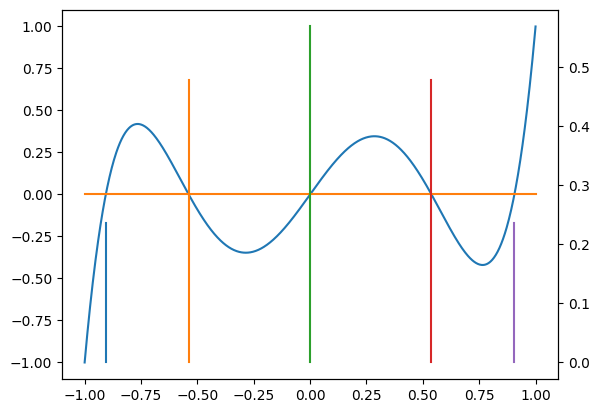

In [5]:
# plot Legendre polynomials
from scipy.special import legendre
import numpy as np
import matplotlib.pyplot as plt
from gaussxw import gaussxw, gaussxwab

# the legendre polynomial outputs a poly2D object
N = int(input("What Legendre polynomial (N) do wish to plot?: ")) 
p = legendre(N)

# evaluate at xpoints
xpoints = np.linspace(-1,1,1000)
ypoints = p(xpoints)


# compare to the sampling locations returned by gaussxw
x,w = gaussxw(N)

x = list(x)
x.sort()
plist = list(p.r)
plist.sort()
print(f"{'Legrendre roots':^17} {'Sampling points using gaussxw':^31}")
for i in range(N):
    print(f"{plist[i]:^17.3f} {x[i]:^31.3f}")

# Overlay the weights  w_k
# create second y-axis
ax1 = plt.gca()
ax2 = ax1.twinx()
ax1.plot (xpoints, ypoints)
ax1.plot([-1,1], [0,0])

# Plot the weights on second y-axis
for i in range(N):
    ax2.plot ([x[i],x[i]], [0,w[i]], '-')

 So this is the Gaussian quadrature approximation to the true integral. The sampling points $x_k$ and weights $w_k$ are calculated for us by the function ```gaussxw``` over the interval (-1,1). All we need to do is map these back into our integration interval as we did above. 

### Approximation error using Gaussian quadrature

Unlike the trapezoidal rule and Simpson's rule there are no general equations we can use to estimate the error on the integral calculated using Gaussian quadrature. 

In general this isn't a problem because the Gaussian quadrature method is so accurate we don't need many sampling points to get a very accurate estimate of the integral (typically $N<100$).

**The accuracy of the estimate increases rapidly with $N$.**

Generally the approximation error improves **by a factor** of $~1/N^2$ as we increase $N$ by $1$. 

For example,  if we increase $N$ from $5$ to $6$, the approximation error decreases by a factor on the order of $25$. Or if we increase $N$ from 10 to 11, the error decreases by a factor of 100.

Because the accuracy increases so rapidly with $N$, if we were to repeat the calculation using $2N$ sampling points (call this estimate $I_2$) , $I_2$ would be so much more accurate than $I_1$, we can treat $I_2$ as being the true value of $I$, so the approximation error on $I_1$ could be estimated as $I_2-I_1$.

Let's try this out for the integral: 

$$
I = \int_0^1 \frac{e^{-({z \over {1-z}})^2}}{(1-z)^2}dz.
$$

We will first calculate the integral using $N=5$, then double the number of sampling points:

In [16]:
# estimate the approximation error of Gaussian quadrature using the doubling method

import numpy as np
import matplotlib.pyplot as plt
from gaussxw import gaussxwab

# define new integrand after change of variable
def f_new(z):
    return np.exp(-(z/(1-z))**2)/(1-z)**2

# define integration range
a = 0
b = 1
N = 5

# first calculate I1 using N sampling points  
xp, wp = gaussxwab(N,a,b)
I1 = np.sum(wp*f_new(xp))

# next calculate I2 using 2N sampling points  
xp, wp = gaussxwab(2*N,a,b)
I2 = np.sum(wp*f_new(xp))

# calculate approximation error on I1
error = np.abs(I2-I1)

# calculate true error on I1
true_error = np.abs(0.5*np.sqrt(np.pi)-I1)

print(f"I1 = {I1:.5f}. I2={I2:.5f}. Error on I1 is about {error:0.5f}")
print(f"The true error is {true_error:0.5f}.")

I1 = 0.91836. I2=0.88706. Error on I1 is about 0.03130
The true error is 0.03213.


How many sampling points does it take to get the solution to within numerical precision?

Let's increase $N$ until we reach our target precision.
Remember the numerical precision of a float $x$ is roughly equal to the error constant $C$ times $x$.

N=62 error=3.3306690738754696e-16


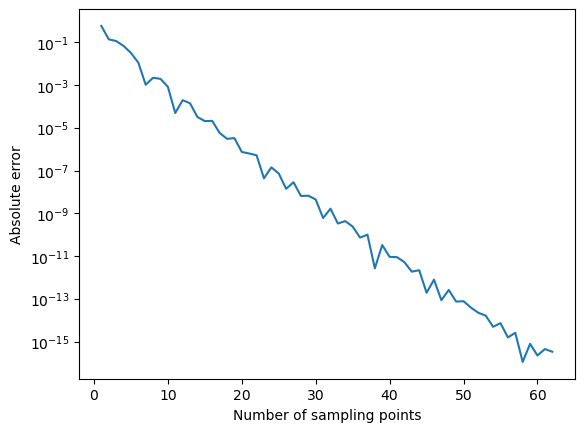

In [17]:
# Investigate accuracy of Gaussian quadrature
# plot N vs accuracy

import numpy as np
import matplotlib.pyplot as plt
from gaussxw import gaussxwab

# define new integrand after change of variable
def f(z):
    return np.exp(-(z/(1-z))**2)/(1-z)**2

# define integration range
a = 0
b = 1

# calculate the numerical uncertainty of estimate based on the true value of the integral
true = 0.5*np.sqrt(np.pi)
C = 1e-16
epsilon = C*true

# create empty lists to hold values of N, error
Nlist = []
error =[]

# initialize variables
N=0
I=0
# increase N by 1 until the approximation error is less than numerical error
while abs(true-I) > epsilon:
    N += 1
    # calculate scaled sampling points and weights
    xp, wp = gaussxwab(N,a,b)
    I = np.sum(wp*f(xp))
    error.append(abs(true-I))
    Nlist.append(N)

# print out next to last N, error since last values are below limit required
print(f"N={Nlist[N-2]} error={error[N-2]}")
plt.plot(Nlist[:-1], error[:-1])
plt.xlabel("Number of sampling points")
plt.ylabel("Absolute error")
plt.yscale("log")

Again, we see the remarkable power of the Gaussian quadrature method. We have reached numerical precision on our estimate with less than 70 sampling points. 


Let's also plot the sampling points and the weights used by the Gaussian quadrature

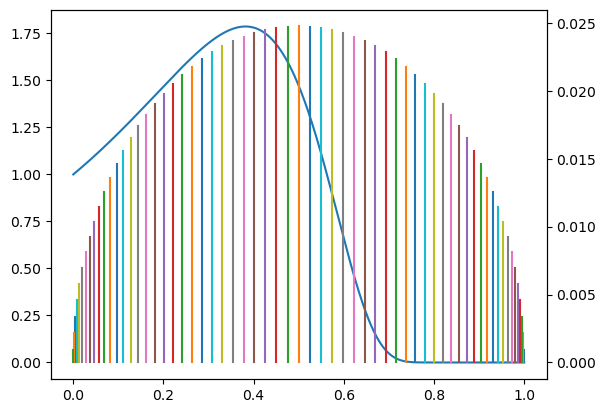

In [18]:
# plot the sampling points and weights of the Gaussian quadrature for the integral above

ax1 = plt.gca()
ax2 = ax1.twinx()

# plot the integrand
ax1.plot (zvalues, y_new)

# Plot the weights on second y-axis
for i in range(0,len(xp)):
    ax2.plot ([xp[i],xp[i]], [0,wp[i]], '-')

Again we see the sampling points are spaced close together at the ends of the interval and farther apart near the middle. However the weights are larger near the middle, so even though the function is not being sampled here as often, these points contribute more to the sum than the end points. 

### Practice Exercise - Gaussian Quadrature

Use Gaussian quadrature to evaluate the following integral with $N=50$ sample points. 

Debye's theory of solids gives the heat capacity of a solid at
temperature $T$ to be

\begin{equation*}
C_V(T) = 9V\rho k_B \biggl( {T\over\theta_D} \biggr)^3 \int_0^{\theta_D/T}
      {x^4 e^x\over(e^x-1)^2}\>d x,
\end{equation*}

where $V$ is the volume of the solid, $\rho$ is the number density of
atoms, $k_B$ is Boltzmann's constant, and $\theta_D$ is the so-called
_Debye temperature_, a property of solids that depends on their
density and speed of sound.

Calculate $C_V$ at $T=300$K for a
  a sample of solid aluminum with volume $V=0.001 \mathrm{m}^{-3}$, a number density of
  $\rho=6.022\times10^{28}\,\mathrm{m}^{-3}$ and a Debye temperature of
  $\theta_D=428\,$K.  
  

  
To save some time, the prefactor in front of the integral is $2.577e3$.

You should find $C_V(T=300K) = $ 2257.80 J/K. 

In [ ]:
### Practice Exercise - Gaussian Quadrature
# Debye's heat capacity



## Integrals over infinite range

There are many integrals in physics problems that are evaluated over an infinite range. For example:
 
The total energy per unit area radiated by a black body at temperature $T$ is
$$
W(T) = {k_B^4 T^4\over4\pi^2c^2\hbar^3} \int_0^\infty {x^3\over e^{x-1}}dx.
$$

---


Since the integration interval is infinite, using one of the integration methods we have learned so far would require an infinite number of sampling points. So what are we to do?

While we could evaluate the integral using an increasing value for the upper limit until the integral converges, we're still left with not knowing when this convergence occurs and so could take many iterations of evaluating the integral until we find it. 

Instead, we can use a change in the integration variable to map the infinite interval to a finite interval.

For an integration range from $0$ to $\infty$:

$$
I = \int_0^\infty f(x) dx,
$$


the standard change of variables is:

$$
z = {x \over {1+x}}.
$$

The integration limits then become:

$$
x=0 \rightarrow z=0,
$$

and

$$
x=\infty \rightarrow z=1.
$$

To find the new integrand $dz$, we need to find $\frac{dx}{dz}$, so first solve the above expression for $x$:

$$
x = z(1+x)
$$

$$
= z + xz
$$

$$
x-xz = z
$$

$$
x(1-z) = z
$$

$$
\boxed{x = {z \over {1-z}}}
$$

Then $\frac{dx}{dz}$ is:

$$
\begin{align*}
\frac{dx}{dz} & = \frac{d(z(1-z)^{-1})}{dz} \\
   & = \left(z(1-z)^{-2} + (1-z)^{-1}\right) \\
   & =\left({z \over {(1-z)^2}} + {1 \over {1-z}}\right) \\
   & = {z + (1-z) \over {(1-z)^2}}  \\
   & \boxed{dx= {dz \over {(1-z)^2}} }
\end{align*}
$$




We then substitute $x$ and $dx$ into the integral:

$$
\int_0^{\infty} f(x) dx \rightarrow \boxed{\int_0^1 f\left({z \over {1-z}}\right) {dz \over {(1-z)^2}}}.
$$




This is a finite interval so we can use any of our integration techniques to evaluate. 

### Practice Exercise - Evaluate an improper integral using Gaussian Quadrature

Evaluate this improper integral using Gaussian Quadrature.

$$
I = \int_0^\infty e^{-t^2}dt
$$

Use the function ```gaussxwab``` from the module ```gaussxw``` to calculate the sampling points and weights. You should get an answer around 0.89. 

In [ ]:
# Practice Exercise - Evaluate an improper integral using Gaussian Quadrature

**Solution**

Make a change of variable:

$$
z = \frac{t}{1+t}
$$

$$
t = \frac{z}{1-z}
$$

$$
t=0 \rightarrow z = 0
$$

$$
t=\infty \rightarrow z =1.
$$

$$
dt = \frac{dz}{1-z^2}
$$

With a change of variable from $t$ to $z$ the integral becomes:

$$
I = \int_0^1 \frac{e^{-({z \over {1-z}})^2}}{(1-z)^2}dz.
$$

At first glance, it certaintly isn't obvious that these two integrals are equivalent. To verify and build some intuition, let's plot and compare the integrand in the original integral with the transformed integrand.

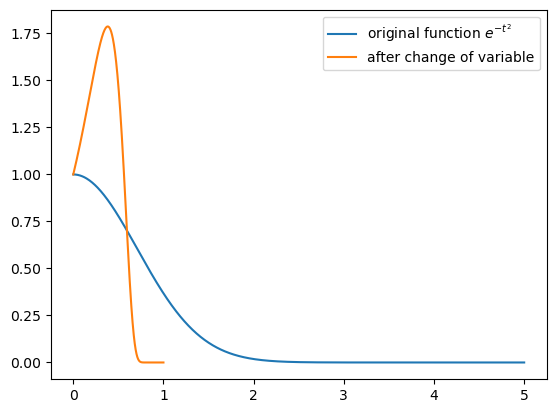

In [2]:
# plot integrands of two equivlent integrals after a change of variable

import numpy as np
import matplotlib.pyplot as plt

# define original integrand
def f_org(t):
    return np.exp(-t*t)

# define new integrand after change of variable
def f_new(z):
    return np.exp(-(z/(1-z))**2)/(1-z)**2


Np=1000
# create t values from t=0,5
tvalues = np.linspace(0, 5, Np)
# calculate y-values from original integrand
y_org = f_org(tvalues)

# create z values. 
# Note at z=1, the integrand denominator=0, so use upper limit
# just below 1
zvalues = np.linspace(0,0.99999, Np)
# calculate y-values from original integrand
y_new = f_new(zvalues)

#plot 
plt.plot(tvalues, y_org, label=r"original function $e^{-t^2}$")
plt.plot(zvalues, y_new, label=r"after change of variable")
plt.legend()
plt.show()

We see that even though the integrands look different, the area under the integrands over their respective intervals looks to be the same. 

So now let's go ahead and calculate the integral using Gaussian quadrature.

In [3]:
# calculate integral with infinite interval using a change of variables and
# Gaussian quadrature

import numpy as np
import matplotlib.pyplot as plt
from gaussxw import gaussxwab




I_forloop = 0.88622693. I_npsum=0.88622693


Compare this result to the area under the integrands in the above plot. Looks to be about right.

The exact value of the integral is ${1 \over 2} \sqrt{\pi} = 0.886226925453$.

 
.**Other infinite integral ranges**

There are other change of variables we can make for other infinite integration intervals. See the textbook for details. Here I just list a summary.

|Interval range| Change of variable| Integral |
|:-------------:|:-------------------:|:--------------------------------:|
|$-\infty \rightarrow a$|$x=-\frac{z}{1+z}$|$\int_{-1}^0\frac{-1}{(1+z)^2}f\left(\frac{-z}{1+z}+a\right)dz$
|$a\rightarrow \infty$|$x=\frac{z}{1-z}+a$|$\int_0^1\frac{1}{(1-z)^2}f\left(\frac{z}{1-z}+a\right)dz$|
|$-\infty \rightarrow \infty$|$x=\frac{z}{1-z^2}$|$\int_{-1}^{1}\frac{1+z^2}{(1-z^2)^2}f(\frac{z}{1-z^2})dz$|



## Multiple integrals

Many physics problems require us to calculate a double or triple integral. This is often the case when we wish to calculate fields or forces from two and three dimensiononal objects. 

For example consider the gravitational force on a point mass a distance $z$ above a sheet of metal with sides of length $L$. 

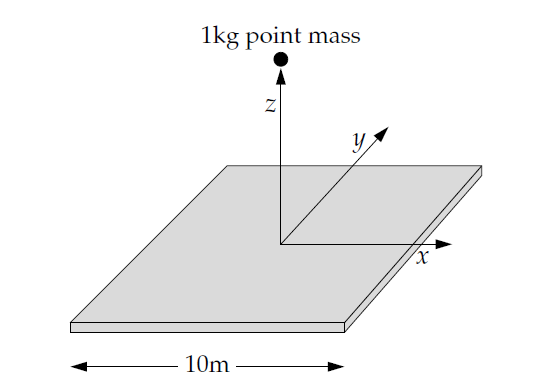


The force is given by the double integral:

$$
F_z = G\sigma z \int_{-L/2}^{L/2}\int_{-L/2}^{L/2} {d x\,d y\over(x^2+y^2+z^2)^{3/2}}\,,
$$

where $\sigma$ is the surface mass density.



Since each unit area of the sheet contributes to the gravitational force at the point, we sum up the gravitational force caused by each differential mass unit $dm=\sigma dx dy$.



Let's look at a generic double integral:

$$
I = \int_0^1\int_0^1f(x,y)dxdy
$$

We can write the inside integral as an integral over the x-axis for a particular choice of $y$:

$$
F(y) = \int_o^1f(x,y)dx
$$

Then the outside integral is just an integral of $F(y)$ over the y-interval:

$$
I = \int_0^1F(y)dy
$$

If we use a numerical integration method to evaluate the integrals, we can write the integrals as the sums:

$$
F(y) \approx \sum_{i=1}^{N_i}w_if(x_i,y)
$$

and

$$
I \approx \sum_{j=1}^{N_j}w_jF(y_j)
$$

Substituting $F(y)$ into the second sum we get:

$$
I \approx \sum_{j=1}^{N_j}\sum_{i=1}^{N_i}w_jw_if(x_i,y_j)
$$

We can see then that we are sampling the 2D function $f(x,y)$ using $N_j\times N_i$ points. These sampling locations do not necessarily have to be along an ordered set of points, they could be randomly chosen or chosen some other way. In general, there is no general formula we can use to optimally choose the sampling points. For now we will use a gridded set of points determined in the same way we choose sampling points for 1D functions.

In this way, you can see from this figure that we are sampling the function $f(x,y)$ in two dimensions along a grid of unevenly spaced points:

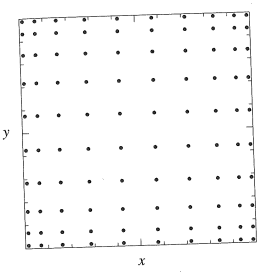




Let's test this out using a modified version of **Exercise 5.21c**.

A continuous distribution of electric charge lies over an $L\times L$ square. The charge density $\sigma$ in $Cm^{-2}$ is given by:

$$
\sigma(x,y) = q_o \sin(\frac{2\pi x}{L})\sin(\frac{2\pi y}{L})
$$

Calculate the potential of the sheet of charge at point P, a location on the xy-plane at x=0, y=Y.

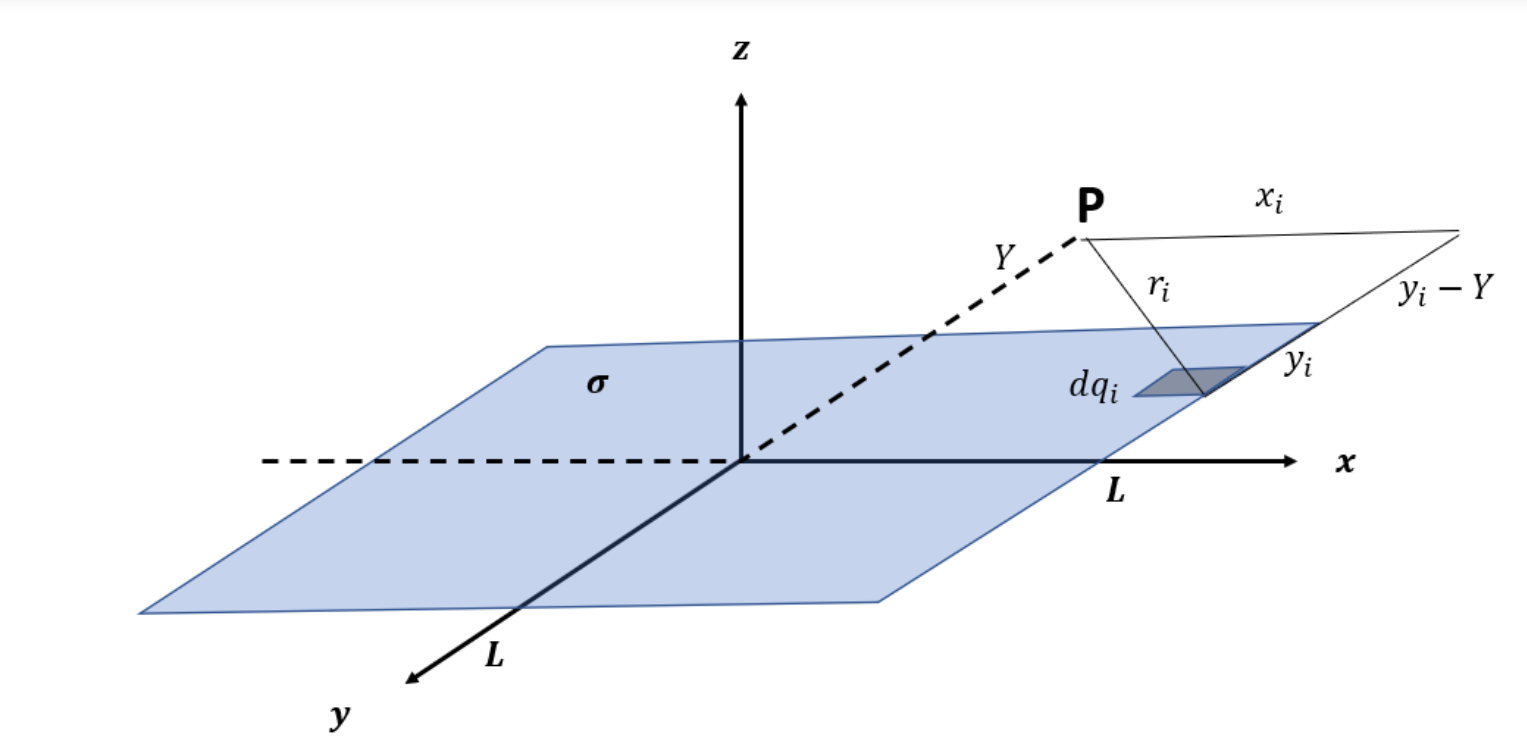


We can write the potential of differential charge $dq_i$ at point $P$ as:

$$
dV_i(P) = k\frac{dq_i}{r_i}
$$

where k is the electric constant, ${1 \over {4\pi\epsilon_0}}$ and $r_i$ is the distance from point $P$ to the charge.

In terms of the charge density, $dq_i=\sigma dx dy$. 

We can write $r$ as $r=\sqrt{x_i^2+(y_i-Y)^2}$, where $Y$ is the distance point $P$ is from the sheet.

Therefore the total potential is given as:

$$
V(P) = \int_{-L/2}^{L/2}\int_{-L/2}^{L/2} \frac{\sigma(x,y)}{\sqrt{x_i^2+(y_i-Y)^2}}dxdy
$$

We can write this:

$$
V(P) = \int_{-L/2}^{L/2}\int_{-L/2}^{L/2} f(x,y)dxdy
$$

where 

$$
f(x,y) = \frac{q_o \sin(\frac{2\pi x}{L})\sin(\frac{2\pi y}{L})}{\sqrt{x_i^2+(y_i-Y)^2}}
$$

If we evaluate the integrals using Gaussian quadrature, the integral is approximated with:


$$
I \approx \sum_{i=1}^N\sum_{j=1}^Nw_iw_jf(x_i,y_i)
$$

where the sampling points and weights for each sum are scaled to the integration interval from -L/2 to L/2.

Let's write the psuedo-code:

```python
# import the functions we need from numpy and gaussxw
# write a user-defined function for f(x,y) that accepts two arguments and returns one value for every set of (x,y)
# Main block of code
# create variables to store N, L, Y, and q_o
# calculate sampling points and weights for N points and scale to our integration range.
# use a nested for-loop to perform the double summation, looping over all N sampling points in both dimensions.
# Within the loop, keep a running sum.
# The last value of the sum is the integral.
```


In [ ]:
# import the functions we need from numpy and gaussxw
# write a user-defined function for f(x,y) that accepts two arguments and returns one value for every set of (x,y)
# Main block of code
# create variables to store N, L, Y, and q_o
# calculate sampling points and weights for N points and scale to our integration range.
# use a nested for-loop to perform the double summation, looping over all N sampling points in both dimensions.
# Within the loop, keep a running sum.
# The last value of the sum is the integral.

###  Practice Exercise - Evaluating a double integral

Practice coding a multiple integral by estimating the following integral. Use Gaussian quadrature with $N=20$ sampling points along each dimension. 

$$
I = \int_{-5}^{5}\int_{-5}^{5} e^{-(x^2+y^2)}{dx}{dy}.
$$


return np.exp(-(x**2 + y**2))
Estimate the error on $I$ by doubling $N$. 

In [19]:
# Practice Exercise - Evaluating a double integral

from gaussxw import gaussxwab
import numpy as np
import matplotlib.pyplot as plt




The integral is 3.142 +/- 5.348e-06.
